# Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cpu device is available


## 1. Загрузка данных.

In [3]:
# do not change the code in the block below
# __________start of block__________
#!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt

with open('onegin.txt', 'r', encoding='utf-8') as iofile:
    text_input = iofile.readlines()

text_input = "".join([x.replace('\t\t', '').lower() for x in text_input])
# __________end of block__________

In [4]:
text_input[:35]

'\ni\n\n«мой дядя самых честных правил,'

## 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [5]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text_input.lower())) + ['<sos>', '<eos>']
num_tokens = len(tokens)

assert num_tokens == 85, "Check the tokenization process"


print("OK")

# __________end of block__________

OK


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

### за дело

Что можно сделать:

0. Просто рнн символ-в-символ
1. По строке выдавать символ
2. Поменять лосс
3. попробовать обучиться на тексте с ошибками (вряд ли разница будет заметна, но всё же. хотя бы попробовать рифму). ван хот кодирование это позволяет делать без изменения кода

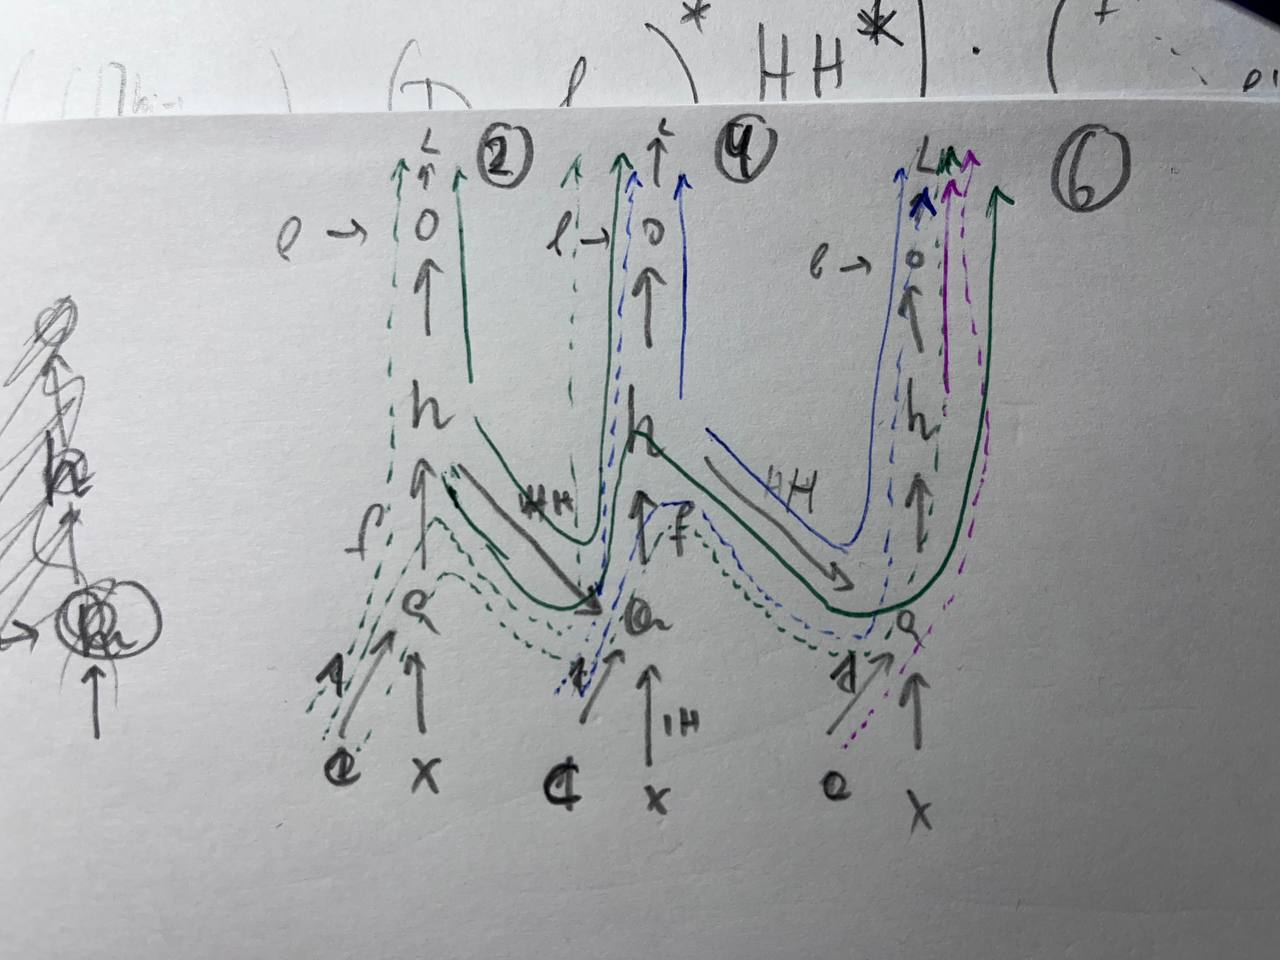

In [30]:
from IPython.display import Image

unfold = Image('unfold.jpg')
display(unfold)

In [31]:
class SimplestRNN:
    def __init__(self,
                tokens, # SHOULD END WITH SOS AND EOS
                neurons=100
    ):
        self.tokens = tokens
        self.num_tokens = len(tokens)
        
        self.token_to_idx = {x: idx for idx, x in enumerate(tokens)}
        self.idx_to_token = {idx: x for idx, x in enumerate(tokens)}

        self.header_token = tokens[-2]
        self.footer_token = tokens[-1]
        self.header_idx = self.token_to_idx[self.header_token]
        self.footer_idx = self.token_to_idx[self.footer_token]


        # hyperparameters

        # parameters
        self.in_dim = self.num_tokens
        self.hid_dim = neurons # hidden state is NOT (log) proba. Output (and input) is
        self.out_dim = self.num_tokens

        self.in2hid = np.random.normal(size=(self.hid_dim, self.in_dim))
        self.hid2hid = np.random.normal(size=(self.hid_dim, self.hid_dim))
        self.hid2out = np.random.normal(size=(self.out_dim, self.hid_dim))

        self.bias_before_activation = np.random.normal(size=self.hid_dim)
        self.out_logproba_bias = np.random.normal(size=self.out_dim)

        # internal
        self.hid = np.random.normal(size=self.hid_dim)
    
    # FIT 
    def fit(self, human_written_text, 
            line_count=256, line_length=100,
            learning_rate=0.3, l2_reg=0.0, clip=None):
        text_encoded = self.encode(human_written_text)
        inputs = self.make_chunks(text_encoded, line_count=line_count, line_length=line_length)

        targets = [x[1:] for x in inputs]
        inputs = [x[:-1] for x in inputs]

        return self.fit_with_chunks(inputs, targets, 
                                    learning_rate=learning_rate, l2_reg=l2_reg, clip=clip)


    def fit_with_chunks(self, 
            inputs,
            targets,
            learning_rate, l2_reg, clip
           ):
        
        for it in range(len(inputs)):
            input_line = inputs[it] 
            target_line = targets[it] 
            loss = 0

            n = len(input_line)

            # history for back propagation
            out_proba_at = [None]
            in_proba_at = [None]
            hid_at = [np.copy(self.hid)]
            out_logproba_at = [None] # -1-st element for back propagation

            for t in range(n):
                out_proba, (in_proba, self.hid, out_logproba,) = self.predict_proba(input_line[t])

                out_proba_at.append(np.copy(out_proba))
                in_proba_at.append(np.copy(in_proba))
                hid_at.append(np.copy(self.hid))
                out_logproba_at.append(np.copy(out_logproba))

                loss += -np.log(out_proba[target_line[t]])
            print(f'Loss on iteration {it} is {loss}')
                    
            # make gradient step 
            in2hid_delta = np.zeros_like(self.in2hid)
            hid2hid_delta = np.zeros_like(self.hid2hid)
            hid2out_delta = np.zeros_like(self.hid2out)

            bias_before_activation_delta = np.zeros_like(self.bias_before_activation)
            out_logproba_bias_delta = np.zeros_like(self.out_logproba_bias)

            param_changes = [
                (self.in2hid, in2hid_delta),
                (self.hid2hid, hid2hid_delta),
                (self.hid2out, hid2out_delta),

                (self.bias_before_activation, bias_before_activation_delta),
                (self.out_logproba_bias, out_logproba_bias_delta),
            ]

            dloss_d_hid_at_t_plus_1 = np.zeros_like(self.hid)

            # back propagation, that is:
            # we want to know grad_param loss
            # But loss depends on params via y:
            # params --f--> y --g--> loss
            # Then grad_params loss = (D_params f)* grad_y loss
            # BECAUSE GRADIENT IS A COvector FIELD!
            for t in reversed(range(1, n+1)):
                # ALL OF THIS COMES FROM UNFOLDING COMPUTATION DIAGRAM 
                # https://www.deeplearningbook.org/contents/rnn.html, 10.2.2

                dloss_d_out_logproba = out_proba_at[t] 
                dloss_d_out_logproba[target_line[t - 1]] -= 1
                # EXCEPT FOR THE TWO LINES ABOVE, NOTHING DEPENDS ON THE CHOICE OF LOSS FUNCTION

                dloss_d_hid_at_t = self.hid2out.T @ dloss_d_out_logproba + dloss_d_hid_at_t_plus_1 # recursive

                activation_derivative_at_hid_t = (1 - hid_at[t] * hid_at[t])
                dloss_d_preactivated_hid_at_t = activation_derivative_at_hid_t * dloss_d_hid_at_t # just (transposed) diagonal matrix

                # param_delta = dloss_dparam, thus the sum
                in2hid_delta += self.outer_vector_product(dloss_d_preactivated_hid_at_t, in_proba_at[t]) # no recursion

                hid2hid_delta += self.outer_vector_product(dloss_d_preactivated_hid_at_t, hid_at[t-1])

                hid2out_delta += self.outer_vector_product(dloss_d_out_logproba, hid_at[t])

                bias_before_activation_delta += dloss_d_preactivated_hid_at_t # recursive
                out_logproba_bias_delta += dloss_d_out_logproba # no recursion

                # WOULD HAVE BEEN MORE INTUITIVE TO PLACE THIS AT THE START OF THE LOOP
                # BUT BREAKS THE FIRST ITERATION :(
                dloss_d_hid_at_t_plus_1 = self.hid2hid.T @ activation_derivative_at_hid_t * dloss_d_preactivated_hid_at_t

            # update params
            for param, param_delta in param_changes:
                if clip:
                    param_delta = np.clip(param_delta, -clip, clip) 
                param += -learning_rate * param_delta

    # PREDICT
    def predict_proba(self, in_token,):
        in_proba = self.token2proba(in_token)
        
        self.hid = self.in2hid @ in_proba + self.hid2hid @ self.hid + self.bias_before_activation
        self.hid = np.tanh(self.hid) # TODO WHY???
        out_logproba = self.hid2out @ self.hid + self.out_logproba_bias # why not use input, too? (extra params for no good reason) 
        out_proba = self.softmax(out_logproba) 

        return out_proba, (in_proba, self.hid, out_logproba,)
    
    def predict_token(self, in_token, temperature):
        out_proba, _ = self.predict_proba(in_token)
        return np.argmax(out_proba)

    # GENERATE
    def generate_encoded(self, seed_phrase=None, max_length=200, temperature=1.0):
        seed_phrase_encoded = self.encode(seed_phrase)

        seed_output = []
        for seed_token in seed_phrase_encoded:
            seed_output.append(self.predict_token(seed_token, temperature))
        
        output = seed_phrase_encoded
        for i in range(max_length):
            output.append(self.predict_token(output[-1], temperature))
        
        return output, seed_output

    def generate(self, seed_phrase=None, max_length=200, temperature=1.0):
        output_encoded, seed_output_encoded = self.generate_encoded(seed_phrase=seed_phrase,
                                                                    max_length=max_length,
                                                                    temperature=temperature)
        return self.decode(output_encoded)

    # AUX
    def encode(self, human_written_text):
        return [self.token_to_idx[x] for x in human_written_text]

    def decode(self, encoded_text):
        return [self.idx_to_token[x] for x in encoded_text]

    def make_chunks(self, text_encoded, line_count, line_length):
        start_index = np.random.randint(0, len(text_encoded) - line_count * line_length)
        chosen_text = text_encoded[start_index:start_index + line_count*line_length]
        print(''.join(self.decode(chosen_text)))
        data = np.array(chosen_text).reshape((line_count, line_length))

        # TODO add footer?
        start_column = np.zeros((line_count, 1), dtype=int) + self.header_idx

        return np.hstack((start_column, data))

    def token2proba(self, token):
        proba = np.zeros(shape=self.num_tokens)
        proba[token] = 1
        return proba

    def proba2token(self, proba):
        return np.argmax(proba)

    def outer_vector_product(self, v, u):
        return v.reshape(len(v), 1) @ u.reshape(1, len(u))

    def softmax(self, x):
        m = np.max(x)
        ex = np.exp(x - m)
        return ex / sum(ex)

#### test

In [32]:
tokens = sorted(set(text_input.lower())) + ['<sos>', '<eos>']
num_tokens = len(tokens)

assert num_tokens == 85, "Check the tokenization process"


print("OK")

OK


In [39]:
srnn = SimplestRNN(tokens)
srnn.fit(human_written_text=text_input, learning_rate=0.1)

тельный и вредный?
я не могу понять. но вот
неполный, слабый перевод,
с живой картины список бледный,
или разыгранный фрейшиц
перстами робких учениц:


письмо татьяны к онегину

я к вам пишу – чего же боле?
что я могу еще сказать?
теперь, я знаю, в вашей воле
меня презреньем наказать.
но вы, к моей несчастной доле
хоть каплю жалости храня,
вы не оставите меня.
сначала я молчать хотела;
поверьте: моего стыда
вы не узнали б никогда,
когда б надежду я имела
хоть редко, хоть в неделю раз
в деревне нашей видеть вас,
чтоб только слышать ваши речи,
вам слово молвить, и потом
всё думать, думать об одном
и день и ночь до новой встречи.
но говорят, вы нелюдим;
в глуши, в деревне всё вам скучно,
а мы… ничем мы не блестим,
хоть вам и рады простодушно.

зачем вы посетили нас?
в глуши забытого селенья
я никогда не знала б вас,
не знала б горького мученья.
души неопытной волненья
смирив со временем (как знать?),
по сердцу я нашла бы друга,
была бы верная супруга
и добродетельная мать.
другой!.. нет, 

In [45]:
print(''.join(srnn.generate("мой дядя самых честных правил")))

мой дядя самых честных правилает ншоеумм
  сечiлонннаро отаиажж таловалт ий
т етимет го
еаим
  
т чтkньснгемот
 анао ,мо  нгт нтионьат начо нмон тль нмаьрстйамол :ьньлтх гт нео  ает н


г

тьео
чшо нгтонаьеонмарс
мооннае «мо


мя


In [46]:

print(''.join(srnn.generate("энцефалит")))

энцефалитет тт

нлкртнпл  ,те нме
ает. отаьт
тви соугжтцо …к8 нта  аго
нат  тв
акдан г
иок нима 
ноьмяо соечцсс сеа
лтки
иает гн етмло нмт
 н
мент 
иаетсн
и 
тмитонатонмет пьлiвер нае aе!  ,цо ниторйпосн…иквг



ПРОБЛЕМА: иногда обучается генерировать тупа один символ. надо псомтреть чо там за семплы
у Карпатого вроде нет такой проблемы, наверное это я

#### advanced

In [ ]:
class TorchRNN:
    pass

In [ ]:
class StrangeRNN:
    def __init__(self, 
                 terminator=1000000):
        self.terminator = terminator

    def fit(self,
            text, token_to_idx, 
    ):
        # dirty
        self.text_encoded = [token_to_idx[x] for x in text]
        words = text.split()
        lens = np.array(list(map(len, words)))

        # to track pairs of words, len should equal len of a single word
        # thus it will match ending of one word with start of another
        # TODO compare to double len. In that case we would track
        # triples of words 
            # TODO check if we believe that lens of coherent words are independent :))))
        # with a single word accounted for quite a lot of times. An effect I find 
        # negative, since a very well (or poorly)-generated word might 
        # overshadow coherence loss
        self.loss_tuple_len = np.round(lens.mean()) + 2 # 7 for whole onegin.txt
        self.text_tuplified = self.tuplify(text)
        
        # fitting itself



    def generate(self, seed_phrase=None, max_length=200, temperature=1.0):
        pass

    # DO I NEED THIS?
    def tuplify(self, seq):
        n = len(seq)
        seq += [self.terminator] * self.loss_tuple_len
        tuplified = np.array([seq[i:i + self.loss_tuple_len] for i in range(n)])
        # TODO cherry pick tuples?
        return tuplified

    def tuple_loss(self, output):
        # should not use 1NN to find closest tuple in text
        # because my tokens are not embedded
            # TODO although letters can be embedded
        # use just Levenstein distance instead
        # TODO prohibit technical tokens, or just ignore them at detokenization :)))
        L = 0.0
        output_tuplified = self.tuplify(output)

        # TODO vectorize
        for tup in output_tuplified:
            matches = (tup == output_tuplified).astype(int).sum(axis=1)
            L += (self.loss_tuple_len - np.max(matches)) 
        
        return L / (self.loss_tuple_len * len(output_tuplified))
    


В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

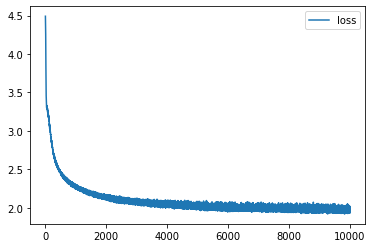

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [ ]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else:
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    #feed the seed phrase, if any

    # your code here

    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [ ]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилас;



xiv

но как потокой.



xii

«я свобред не словавран в скорей,
для с посвялесь мне моловой,
те ты,
перегиной в тям праздной
и привезут перваю вся вновся сквозь ти стала сблился,
и старый свимарной таня обратель любова не когда и нет волностье нежной
тишен,
перестоком.
«поже постаничив очествы
в и старько забаньем и заковенью,
ее своя моднать наводушта;
какой нет поли своем горозный и быле и, законно он ходушних недважный плая
с за стра.



xvii




xxvi

все 


## Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [ ]:
seed_phrase = ' мой дядя самых честных правил'

In [ ]:
generated_phrases = # your code here

# For example:

# generated_phrases = [
#     generate_sample(
#         model,
#         ' мой дядя самых честных правил',
#         max_length=500,
#         temperature=1.
#     ).replace('<sos>', '')
#     for _ in range(10)
# ]

In [ ]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'


submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

На этом задание завершено. Поздравляем!

# На всём готовеньком
https://gist.github.com/karpathy/d4dee566867f8291f086

In [ ]:
"""
Minimal character-level Vanilla RNN model. Written by Andrej Karpathy (@karpathy)
BSD License
"""
import numpy as np

# data I/O
data = open('onegin.txt', 'r', encoding='utf-8').read() # should be simple plain text file
chars = list(set(data))
data_size, vocab_size = len(data), len(chars)
char_to_ix = { ch:i for i,ch in enumerate(chars) }
ix_to_char = { i:ch for i,ch in enumerate(chars) }

# hyperparameters
hidden_size = 100 # size of hidden layer of neurons
seq_length = 25 # number of steps to unroll the RNN for
learning_rate = 1e-1

# model parameters
Wxh = np.random.randn(hidden_size, vocab_size)*0.01 # input to hidden
Whh = np.random.randn(hidden_size, hidden_size)*0.01 # hidden to hidden
Why = np.random.randn(vocab_size, hidden_size)*0.01 # hidden to output
bh = np.zeros((hidden_size, 1)) # hidden bias
by = np.zeros((vocab_size, 1)) # output bias

def lossFun(inputs, targets, hprev):
  """
  inputs,targets are both list of integers.
  hprev is Hx1 array of initial hidden state
  returns the loss, gradients on model parameters, and last hidden state
  """
  xs, hs, ys, ps = {}, {}, {}, {}
  hs[-1] = np.copy(hprev)
  loss = 0
  # forward pass
  for t in range(len(inputs)):
    xs[t] = np.zeros((vocab_size,1)) # encode in 1-of-k representation
    xs[t][inputs[t]] = 1
    hs[t] = np.tanh(np.dot(Wxh, xs[t]) + np.dot(Whh, hs[t-1]) + bh) # hidden state
    ys[t] = np.dot(Why, hs[t]) + by # unnormalized log probabilities for next chars
    ps[t] = np.exp(ys[t]) / np.sum(np.exp(ys[t])) # probabilities for next chars
    loss += -np.log(ps[t][targets[t],0]) # softmax (cross-entropy loss)
  # backward pass: compute gradients going backwards
  dWxh, dWhh, dWhy = np.zeros_like(Wxh), np.zeros_like(Whh), np.zeros_like(Why)
  dbh, dby = np.zeros_like(bh), np.zeros_like(by)
  dhnext = np.zeros_like(hs[0])
  for t in reversed(range(len(inputs))):
    dy = np.copy(ps[t])
    dy[targets[t]] -= 1 # backprop into y. see http://cs231n.github.io/neural-networks-case-study/#grad if confused here
    dWhy += np.dot(dy, hs[t].T)
    dby += dy
    dh = np.dot(Why.T, dy) + dhnext # backprop into h
    dhraw = (1 - hs[t] * hs[t]) * dh # backprop through tanh nonlinearity
    dbh += dhraw
    dWxh += np.dot(dhraw, xs[t].T)
    dWhh += np.dot(dhraw, hs[t-1].T)
    dhnext = np.dot(Whh.T, dhraw)
  for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
    np.clip(dparam, -5, 5, out=dparam) # clip to mitigate exploding gradients
  return loss, dWxh, dWhh, dWhy, dbh, dby, hs[len(inputs)-1]

def sample(h, seed_ix, n):
  """ 
  sample a sequence of integers from the model 
  h is memory state, seed_ix is seed letter for first time step
  """
  x = np.zeros((vocab_size, 1))
  x[seed_ix] = 1
  ixes = []
  for t in range(n):
    h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
    y = np.dot(Why, h) + by
    p = np.exp(y) / np.sum(np.exp(y))
    ix = np.random.choice(range(vocab_size), p=p.ravel())
    x = np.zeros((vocab_size, 1))
    x[ix] = 1
    ixes.append(ix)
  return ixes

n, p = 0, 0
mWxh, mWhh, mWhy = np.zeros_like(Wxh), np.zeros_like(Whh), np.zeros_like(Why)
mbh, mby = np.zeros_like(bh), np.zeros_like(by) # memory variables for Adagrad
smooth_loss = -np.log(1.0/vocab_size)*seq_length # loss at iteration 0
while True:
  # prepare inputs (we're sweeping from left to right in steps seq_length long)
  if p+seq_length+1 >= len(data) or n == 0: 
    hprev = np.zeros((hidden_size,1)) # reset RNN memory
    p = 0 # go from start of data
  inputs = [char_to_ix[ch] for ch in data[p:p+seq_length]]
  targets = [char_to_ix[ch] for ch in data[p+1:p+seq_length+1]]

  # sample from the model now and then
  if n % 100 == 0:
    sample_ix = sample(hprev, inputs[0], 200)
    txt = ''.join(ix_to_char[ix] for ix in sample_ix)
    print('--------------------------')
    print(txt)
    print('--------------------------')

  # forward seq_length characters through the net and fetch gradient
  loss, dWxh, dWhh, dWhy, dbh, dby, hprev = lossFun(inputs, targets, hprev)
  smooth_loss = smooth_loss * 0.999 + loss * 0.001
  if n % 100 == 0: 
    print(f'iter {n}, loss: {smooth_loss}')   

  # perform parameter update with Adagrad
  for param, dparam, mem in zip([Wxh, Whh, Why, bh, by], 
                                [dWxh, dWhh, dWhy, dbh, dby], 
                                [mWxh, mWhh, mWhy, mbh, mby]):
    mem += dparam * dparam
    param += -learning_rate * dparam / np.sqrt(mem + 1e-8) # adagrad update

  p += seq_length # move data pointer
  n += 1 # iteration counter 

--------------------------
ЖщШl)q9!ЗйmлЗРkДх«Aтd(,яf(э9бТъПИУQК -klУ–,М–РW«987шYАIhу€дБнъшС,«фшDВс,anСюхкд—bЧиT5ОяунlТаРdдзыQ-QёВkrYл:hpAхfXж—ЗБтьВ]GGвЯYЕ»юбб^КH–Нщгр7tAП-ц’й)ЭДЯc?о58Б(яИ«д€вGлтЧXiянlц8сФгeM;(Рпc 8ДCжr.VGШдж«яv
--------------------------
iter 0, loss: 121.30075566756192
--------------------------
а	тлитао	хброоаино ошиe 	оВе
 н	п
 	но,всо, м Рpд
дтс	 чз aаня
	мео о	у  
томнк 	цливяяжт  йРделн саоелсосоп ,ииде рчбл	 	Тыеао	н
оооа дIонабтхмтотв
еныещх нВм	
еоав, ре япуе i н, ряз	сераалия  в хdое
--------------------------
iter 100, loss: 121.33603021713128
--------------------------

ы
 . :ннляс а	дрожКИ сеь	пиор
а лди ч	ь узВВнки 	т с»тв.а 	
чкау
  дд мж	аонис	ддур ,екуя 	о н,т	 ьур деомп 	 уЮ змвлраерлdе и йгКт	маку
итНжицр	реийж	твнг
Пнме 
сеео аллдн ыиКаы о ееяб леерноь		кн	Б
--------------------------
iter 200, loss: 118.48878871934942
--------------------------
п	тпег		лоьево ;Iыд			т	еяа
уж,г ;ы
			 лр		 л
		яяе
	ихщилшш
щ;жи Чш	лссс окесги у,,оса;ьсн ке сшслтаиД


KeyboardInterrupt: 